In [1]:
from google.colab import files
files.upload()

Saving q2_customers.csv to q2_customers.csv


{'q2_customers.csv': b'age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased\n30,43075,9,2080,45,6\n19,14496,11,454,8,3\n43,57632,6,2144,16,4\n30,15629,10,801,0,2\n19,14901,16,396,17,1\n46,54692,10,2593,50,4\n35,26579,8,2694,51,3\n22,9158,14,591,6,1\n18,20782,10,571,11,2\n40,29838,11,930,11,4\n20,9403,16,478,0,3\n62,98014,2,5156,56,8\n41,58697,9,1417,45,4\n31,18494,16,877,2,3\n37,40544,11,1433,17,3\n44,35928,7,1192,14,4\n43,50063,6,1497,43,4\n25,24491,19,716,18,3\n59,98677,4,7062,161,9\n48,32549,6,1682,23,6\n44,46673,10,1965,37,4\n49,35367,7,1432,13,5\n56,67796,3,4220,54,6\n42,37122,10,1377,51,3\n25,8712,18,463,13,2\n46,37282,8,1821,53,3\n39,44010,5,2035,26,5\n59,75583,4,6815,61,8\n23,8854,16,878,9,3\n48,84657,1,3684,51,8\n38,27402,11,2227,54,4\n46,30943,8,2964,13,5\n35,35382,6,2787,45,5\n68,107452,1,6652,162,9\n25,9315,10,509,6,1\n63,104494,3,7180,152,7\n42,47437,5,2079,39,6\n28,14431,11,578,19,3\n51,98892,1,4966,101,9\n29,15156,10,459,3,3\n32,27

In [2]:
import pandas as pd

df = pd.read_csv("q2_customers.csv")
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(df)

Feature scaling is essential before applying K-Means because it ensures all features contribute equally to distance calculations.

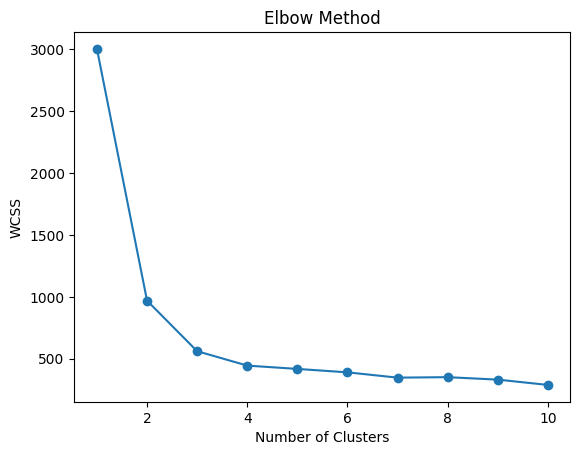

In [4]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

The elbow point is observed at K = 3, where the rate of decrease in WCSS slows down significantly. Therefore, the optimal number of clusters is 3.

In [5]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)

df['cluster'] = clusters
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [6]:
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


Each cluster represents a group of customers with similar behavior patterns.

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

PCA reduces the dataset into two principal components for visualization.

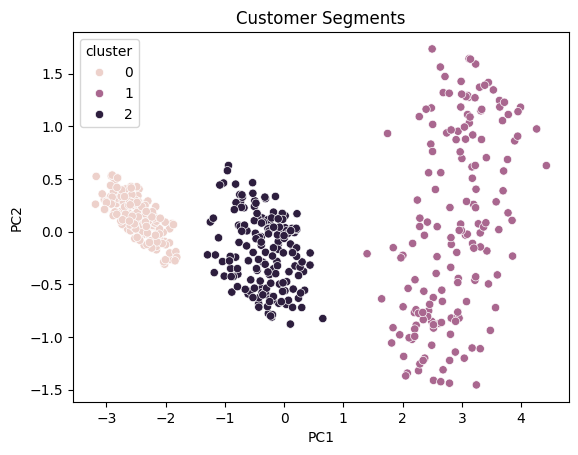

In [8]:
import seaborn as sns

sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=df)
plt.title("Customer Segments")
plt.show()

The scatter plot shows distinct customer segments formed by clustering.